In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Base path — apunta a la carpeta excel
EXCEL_PATH = Path('../data/excel')
CSV_PATH = Path('../data/sales_sv_2024.csv')

In [3]:
df_sales = pd.read_csv(CSV_PATH)
df_budget_vs_actual = pd.read_excel(EXCEL_PATH / 'budget_vs_actual.xlsm', sheet_name='Budget_vs_Actual')
df_employees = pd.read_excel(EXCEL_PATH / 'employees.xlsm', sheet_name='KPIs')
df_suppliers = pd.read_excel(EXCEL_PATH / 'suppliers.xlsm', sheet_name='Margin_Analysis')
df_marketing_campaign = pd.read_excel(EXCEL_PATH / 'marketing_campaigns.xlsm', sheet_name='ROI_Analysis')

## 📊 Data Exploration

In [4]:
dataframes = {
    'Sales': df_sales,
    'Budget vs Actual': df_budget_vs_actual,
    'Employees': df_employees,
    'Suppliers': df_suppliers,
    'Campaigns': df_marketing_campaign
}

for name, df in dataframes.items():
    print(f'\n{"="*50}')
    print(f'📋 {name} — {df.shape[0]} rows, {df.shape[1]} columns')
    print('='*50)
    display(df.head())


📋 Sales — 2000 rows, 17 columns


,sale_id,date,month,weekday,branch_id,branch_name,department,product_id,product_name,category,unit_price,discount,final_price,quantity,total,payment_method,customer_id
0,1,2024-05-20,5,Monday,1,San Salvador Centro,San Salvador,4,Yuca frita,Traditional Food,2.50,0.0,2.50,8,20.00,Cash,53
1,2,2024-10-29,10,Tuesday,2,Santa Ana,Santa Ana,18,Curtido en frasco,Groceries,2.00,0.0,2.00,14,28.00,Cash,112
2,3,2024-10-14,10,Monday,1,San Salvador Centro,San Salvador,8,Fresco de tamarindo,Beverages,0.75,0.1,0.68,7,4.76,Debit card,280
3,4,2024-08-17,8,Saturday,4,Soyapango,San Salvador,14,Frijoles rojos 1lb,Groceries,1.20,0.0,1.20,19,22.80,Credit card,4
4,5,2024-06-23,6,Sunday,7,La Libertad,La Libertad,6,Kolachampán,Beverages,0.75,0.0,0.75,9,6.75,Cash,391



📋 Budget vs Actual — 8 rows, 6 columns


,branch_name,budget_usd,actual_usd,variance,achievement_pct,status
0,San Salvador Centro,21600,14121.15,-7478.85,0.653757,🔴 Below Target
1,Santa Ana,19200,13615.80,-5584.20,0.709156,🟡 At Risk
2,San Miguel,18000,11621.12,-6378.88,0.645618,🔴 Below Target
3,Soyapango,19200,11993.03,-7206.97,0.624637,🔴 Below Target
4,Metrocentro,20400,13151.56,-7248.44,0.644684,🔴 Below Target



📋 Employees — 8 rows, 7 columns


,branch_name,total_payroll,headcount,actual_usd,revenue_per_employee,payroll_ratio,efficiency_status
0,Chalatenango,1630,3,16334.34,5444.780000,0.099790,🟢 High
1,La Libertad,1630,3,10665.51,3555.170000,0.152829,🔴 Low
2,Metrocentro,1630,3,13151.56,4383.853333,0.123940,🟡 Medium
3,San Miguel,1630,3,11621.12,3873.706667,0.140262,🔴 Low
4,San Salvador Centro,1630,3,14121.15,4707.050000,0.115430,🟡 Medium



📋 Suppliers — 18 rows, 6 columns


,product_name,category,cost_usd,unit_price,margin_usd,margin_pct
0,Pupusas de queso,Traditional Food,0.25,0.5,0.25,0.50
1,Pupusas de frijol,Traditional Food,0.20,0.5,0.30,0.60
2,Tamales de elote,Traditional Food,0.55,1.0,0.45,0.45
3,Yuca frita,Traditional Food,1.20,2.5,1.30,0.52
4,Atol de elote,Beverages,0.45,1.0,0.55,0.55



📋 Campaigns — 12 rows, 11 columns


,campaign_name,channel,target_category,investment_usd,revenue_generated,roi_usd,roi_pct %,revenue_by_period,roi_pct_adjusted,start_date,end_date
0,Verano Tipico 2024,Social Media,Traditional Food,500,5407.20,4907.20,10.814400,383.63,0.767260,2024-01-15,2024-02-15
1,San Valentin Bebidas,Email,Beverages,300,4456.88,4156.88,14.856267,183.02,0.610067,2024-02-01,2024-02-14
2,Semana Santa Artesanias,Social Media,Handicrafts,750,61934.90,61184.90,82.579867,2908.25,3.877667,2024-03-20,2024-04-05
3,Dia de la Madre,Email,Clothing,400,18507.60,18107.60,46.269000,357.30,0.893250,2024-05-01,2024-05-10
4,Promo Lacteos Junio,In-Store,Dairy,250,5982.30,5732.30,23.929200,438.82,1.755280,2024-06-01,2024-06-30


## 🔍 Data Quality Check

In [5]:
# Muestra la sumatoria de valores vacíos y duplicados
for name, df in dataframes.items():
    print(f'\n{"="*50}')
    print(f'📋 {name}')
    print('='*50)
    print('Null values:')
    display(df.isnull().sum())
    print(f'Duplicate rows: {df.duplicated().sum()}')


📋 Sales
Null values:


sale_id           0
date              0
month             0
weekday           0
branch_id         0
branch_name       0
department        0
product_id        0
product_name      0
category          0
unit_price        0
discount          0
final_price       0
quantity          0
total             0
payment_method    0
customer_id       0
dtype: int64

Duplicate rows: 0

📋 Budget vs Actual
Null values:


branch_name        0
budget_usd         0
actual_usd         0
variance           0
achievement_pct    0
status             0
dtype: int64

Duplicate rows: 0

📋 Employees
Null values:


...

Duplicate rows: 0

📋 Suppliers
Null values:


product_name    0
category        0
cost_usd        0
unit_price      0
margin_usd      0
margin_pct      0
dtype: int64

Duplicate rows: 0

📋 Campaigns
Null values:


campaign_name        0
channel              0
target_category      0
investment_usd       0
revenue_generated    0
roi_usd              0
roi_pct %            0
revenue_by_period    0
roi_pct_adjusted     0
start_date           0
end_date             0
dtype: int64

Duplicate rows: 0


## 🔗 Data Integration — Merging Sources

In [6]:
# Union de columnas, quitando las que ya existen en sales, de suppliers para no duplicar
df_suppliers_slim = df_suppliers[['product_name', 'cost_usd']]
df_merged = pd.merge(df_sales, df_suppliers_slim, on='product_name', how='left')
print(df_merged.shape)
df_merged[['product_name', 'unit_price', 'cost_usd']].head(10)

(2000, 18)


,product_name,unit_price,cost_usd
0,Yuca frita,2.50,1.20
1,Curtido en frasco,2.00,0.90
2,Fresco de tamarindo,0.75,0.30
3,Frijoles rojos 1lb,1.20,0.65
4,Kolachampán,0.75,0.35
5,Jarrito de barro,8.00,3.50
6,Camisa guayabera,18.00,9.00
7,Tamales de elote,1.00,0.55
8,Tamales de elote,1.00,0.55
9,Fresco de tamarindo,0.75,0.30


In [7]:
df_merged['margin_usd'] = df_merged['unit_price'] - df_merged['cost_usd']
df_merged[['product_name', 'unit_price', 'cost_usd', 'margin_usd']].head(10)

,product_name,unit_price,cost_usd,margin_usd
0,Yuca frita,2.50,1.20,1.30
1,Curtido en frasco,2.00,0.90,1.10
2,Fresco de tamarindo,0.75,0.30,0.45
3,Frijoles rojos 1lb,1.20,0.65,0.55
4,Kolachampán,0.75,0.35,0.40
5,Jarrito de barro,8.00,3.50,4.50
6,Camisa guayabera,18.00,9.00,9.00
7,Tamales de elote,1.00,0.55,0.45
8,Tamales de elote,1.00,0.55,0.45
9,Fresco de tamarindo,0.75,0.30,0.45


In [8]:
df_merged['margin_total'] = df_merged['margin_usd'] * df_merged['quantity']
df_merged['margin_pct'] = df_merged['margin_usd'] / df_merged['unit_price'] * 100
df_merged[['product_name', 'unit_price', 'cost_usd', 'margin_usd', 'margin_total', 'margin_pct']].head(10)

,product_name,unit_price,cost_usd,margin_usd,margin_total,margin_pct
0,Yuca frita,2.50,1.20,1.30,10.40,52.000000
1,Curtido en frasco,2.00,0.90,1.10,15.40,55.000000
2,Fresco de tamarindo,0.75,0.30,0.45,3.15,60.000000
3,Frijoles rojos 1lb,1.20,0.65,0.55,10.45,45.833333
4,Kolachampán,0.75,0.35,0.40,3.60,53.333333
5,Jarrito de barro,8.00,3.50,4.50,58.50,56.250000
6,Camisa guayabera,18.00,9.00,9.00,162.00,50.000000
7,Tamales de elote,1.00,0.55,0.45,9.00,45.000000
8,Tamales de elote,1.00,0.55,0.45,3.60,45.000000
9,Fresco de tamarindo,0.75,0.30,0.45,4.05,60.000000


## 📊 Analysis — Margin by Category

In [9]:
margin_by_category = df_merged.groupby('category').agg({
    'margin_pct': 'mean',
    'margin_total': 'sum'
}).sort_values('margin_total', ascending=False)

margin_by_category

,margin_pct,margin_total
category,,
Handicrafts,52.891762,32788.00
Clothing,50.000000,9702.00
Groceries,46.070344,3555.15
Dairy,50.952381,3116.80
Traditional Food,51.580931,2858.25
Beverages,56.176471,2609.95


## 📈 Visualization — Margin by Category

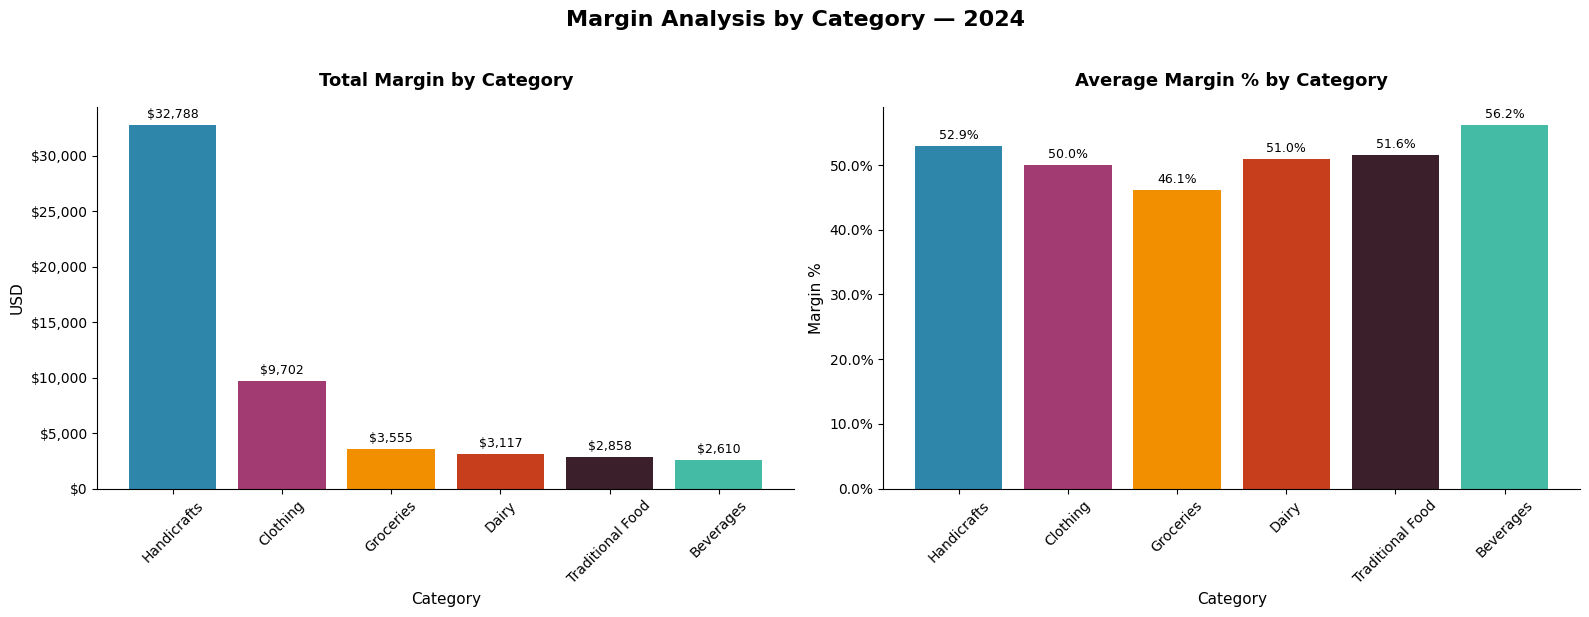

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Margin Analysis by Category — 2024', fontsize=16, fontweight='bold', y=1.02)

# Colors
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']

# Chart 1 — Total Margin
bars1 = ax1.bar(margin_by_category.index, margin_by_category['margin_total'], color=colors)
ax1.set_title('Total Margin by Category', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Category', fontsize=11)
ax1.set_ylabel('USD', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)
ax1.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 — Margin Percentage
bars2 = ax2.bar(margin_by_category.index, margin_by_category['margin_pct'], color=colors)
ax2.set_title('Average Margin % by Category', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Category', fontsize=11)
ax2.set_ylabel('Margin %', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(axis='x', rotation=45)
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 🔗 Merging Budget Data

In [11]:
df_budget_slim = df_budget_vs_actual[['branch_name', 'budget_usd', 'variance', 'achievement_pct', 'status']]
df_budget_merged = pd.merge(df_merged, df_budget_slim, on='branch_name', how='left')
df_budget_merged.shape

(2000, 25)

## 🔗 Merging Employee KPIs

In [12]:
df_employees_slim = df_employees[['branch_name', 'total_payroll', 'headcount', 'revenue_per_employee', 'payroll_ratio', 'efficiency_status']]
df_kpis_merged = pd.merge(df_budget_merged, df_employees_slim, on='branch_name', how='left')
df_kpis_merged.shape

(2000, 30)

## 🔗 Merging Marketing Campaigns

In [13]:
df_campaigns_slim = df_marketing_campaign[['target_category', 'campaign_name', 'channel', 'investment_usd', 'roi_pct_adjusted']]
df_campaigns_agg = df_campaigns_slim.groupby('target_category').agg({
    'investment_usd': 'sum',
    'roi_pct_adjusted': 'mean',
    'campaign_name': 'count'
}).reset_index()
df_campaigns_agg.rename(columns={'campaign_name': 'num_campaigns'}, inplace=True)
df_all_merged = pd.merge(df_kpis_merged, df_campaigns_agg, left_on='category', right_on='target_category', how='left')
df_all_merged.shape

(2000, 34)

## 💾 Export Master Dataset

In [14]:
output_path = Path('../data/master_dataset.csv')
df_all_merged.to_csv(output_path, index=False)
print(f'✅ Master dataset exported: {df_all_merged.shape[0]} rows, {df_all_merged.shape[1]} columns')
print(f'📁 Saved at: {output_path}')

✅ Master dataset exported: 2000 rows, 34 columns
📁 Saved at: ..\data\master_dataset.csv
